In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

os.makedirs('images', exist_ok=True)

print("Libraries loaded.")

Libraries loaded.


In [5]:
campaigns = pd.read_csv('data/campaigns.csv')
customers = pd.read_csv('data/customers.csv')
sessions = pd.read_csv('data/website_sessions.csv')

print("Data loaded.")

Data loaded.


In [6]:
# Create binary variables from categorical columns
campaigns['Is_B2C'] = (campaigns['TargetAudience'] == 'B2C').astype(int)
campaigns['Is_Mobile'] = (campaigns['DeviceTarget'] == 'Mobile').astype(int)
campaigns['Is_Retention'] = (campaigns['CampaignObjective'] == 'Retention').astype(int)
campaigns['Is_Conversion'] = (campaigns['CampaignObjective'] == 'Conversion').astype(int)

# One-hot encode categorical variables with reference categories
# Reference: Google Ads (PlatformID=1), Search (CampaignTypeID=1), Real Estate (IndustryID=10)
platform_dummies = pd.get_dummies(campaigns['PlatformID'], prefix='Platform', drop_first=True)
type_dummies = pd.get_dummies(campaigns['CampaignTypeID'], prefix='Type', drop_first=True)
industry_dummies = pd.get_dummies(campaigns['IndustryID'], prefix='Industry', drop_first=True)

# Build feature matrix for ROI and Revenue models
X = pd.concat([
    campaigns[['Budget', 'CampaignDuration']],
    platform_dummies,
    type_dummies,
    industry_dummies,
    campaigns[['Is_B2C', 'Is_Mobile', 'Is_Retention', 'Is_Conversion']]
], axis=1).astype(float)

y_roi = campaigns['ROI'].astype(float)
y_revenue = campaigns['Revenue'].astype(float)

print(f"Features shape: {X.shape}")
print(f"ROI target shape: {y_roi.shape}")
print(f"Revenue target shape: {y_revenue.shape}")

Features shape: (10000, 26)
ROI target shape: (10000,)
Revenue target shape: (10000,)


In [7]:
# Simple linear regression
X_simple = campaigns[['Budget']]
X_simple_const = sm.add_constant(X_simple)
model1 = sm.OLS(y_revenue, X_simple_const).fit()

print("Model 1: Budget → Revenue")
print("-" * 40)
print(f"R-squared: {model1.rsquared:.4f}")
print(f"Coefficient (Budget): {model1.params[1]:.4f}")
print(f"p-value: {model1.pvalues[1]:.6f}")
print(f"Interpretation: Each $1 increase in budget is associated with ${model1.params[1]:.2f} increase in revenue")

Model 1: Budget → Revenue
----------------------------------------
R-squared: 0.2164
Coefficient (Budget): 6.2536
p-value: 0.000000
Interpretation: Each $1 increase in budget is associated with $6.25 increase in revenue


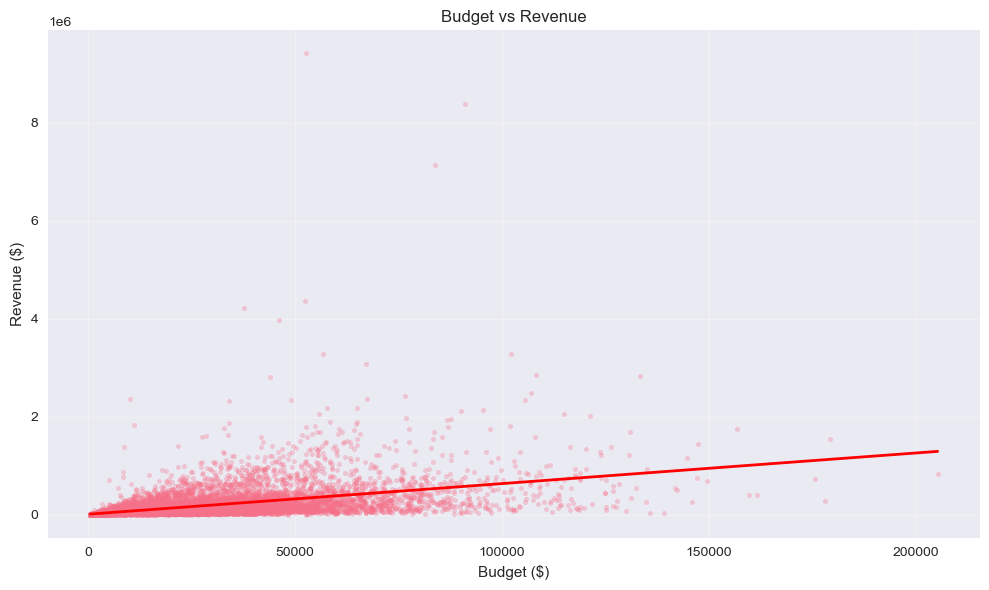

In [8]:
# Scatter plot with regression line
plt.figure(figsize=(10, 6))
plt.scatter(campaigns['Budget'], campaigns['Revenue'], alpha=0.3, s=10)

# Regression line
x_range = np.linspace(campaigns['Budget'].min(), campaigns['Budget'].max(), 100)
y_pred = model1.params[0] + model1.params[1] * x_range
plt.plot(x_range, y_pred, 'red', linewidth=2)

plt.xlabel('Budget ($)')
plt.ylabel('Revenue ($)')
plt.title('Budget vs Revenue')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('images/budget_revenue_regression.png', dpi=300)
plt.show()

In [9]:
# Multiple regression with proper one-hot encoding
X_const = sm.add_constant(X)
model2 = sm.OLS(y_roi, X_const).fit()

print("Model 2: Campaign Characteristics → ROI")
print("-" * 40)
print(f"R-squared: {model2.rsquared:.4f}")
print(f"Adjusted R-squared: {model2.rsquared_adj:.4f}")
print(f"F-statistic: {model2.fvalue:.2f}")
print(f"p-value: {model2.f_pvalue:.6f}")

# Find significant predictors
sig_predictors = model2.pvalues[model2.pvalues < 0.05]
print(f"\nSignificant predictors (p < 0.05): {len(sig_predictors) - 1}")

for var in sig_predictors.index:
    if var != 'const':
        print(f"  {var}: coef={model2.params[var]:.3f}, p={model2.pvalues[var]:.4f}")

Model 2: Campaign Characteristics → ROI
----------------------------------------
R-squared: 0.0220
Adjusted R-squared: 0.0195
F-statistic: 8.64
p-value: 0.000000

Significant predictors (p < 0.05): 6
  Platform_2: coef=-13.961, p=0.0041
  Platform_3: coef=-21.735, p=0.0000
  Platform_4: coef=-29.041, p=0.0000
  Platform_5: coef=-39.307, p=0.0000
  Platform_6: coef=-49.036, p=0.0000
  Platform_7: coef=-58.579, p=0.0000


In [10]:
# Model 3 uses the same features but predicts revenue
model3 = sm.OLS(y_revenue, X_const).fit()

print("Model 3: Campaign Characteristics → Revenue")
print("-" * 40)
print(f"R-squared: {model3.rsquared:.4f}")
print(f"Adjusted R-squared: {model3.rsquared_adj:.4f}")
print(f"F-statistic: {model3.fvalue:.2f}")
print(f"p-value: {model3.f_pvalue:.6f}")

sig_predictors = model3.pvalues[model3.pvalues < 0.05]
print(f"\nSignificant predictors (p < 0.05): {len(sig_predictors) - 1}")

for var in sig_predictors.index:
    if var != 'const':
        print(f"  {var}: coef={model3.params[var]:.2f}, p={model3.pvalues[var]:.4f}")

Model 3: Campaign Characteristics → Revenue
----------------------------------------
R-squared: 0.4366
Adjusted R-squared: 0.4352
F-statistic: 297.29
p-value: 0.000000

Significant predictors (p < 0.05): 12
  Budget: coef=6.27, p=0.0000
  Platform_2: coef=-303688.80, p=0.0000
  Platform_3: coef=-321439.86, p=0.0000
  Platform_4: coef=-287906.20, p=0.0000
  Platform_5: coef=-403848.48, p=0.0000
  Platform_6: coef=-451443.77, p=0.0000
  Platform_7: coef=-390809.82, p=0.0000
  Type_2: coef=-26300.33, p=0.0008
  Type_3: coef=-23513.52, p=0.0028
  Type_4: coef=-50622.96, p=0.0000
  Type_5: coef=-63697.92, p=0.0000
  Type_6: coef=-118847.84, p=0.0000


In [11]:
# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data['Feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("Multicollinearity Check (VIF)")
print("-" * 40)
print("VIF > 10 indicates high multicollinearity")
print(vif_data.head(10).to_string(index=False))

Multicollinearity Check (VIF)
----------------------------------------
VIF > 10 indicates high multicollinearity
         Feature      VIF
CampaignDuration 6.010343
          Is_B2C 2.674168
          Budget 2.350690
          Type_4 1.846214
      Platform_2 1.845463
      Platform_7 1.843146
          Type_2 1.840453
          Type_5 1.835558
      Platform_3 1.827335
          Type_3 1.827265


In [12]:
# Prepare session data
session_features = sessions[['SessionDuration', 'PagesViewed', 'Device', 'TrafficSource', 'CustomerID']].copy()

# One-hot encode categorical variables
device_dummies = pd.get_dummies(session_features['Device'], prefix='Device', drop_first=True)
traffic_dummies = pd.get_dummies(session_features['TrafficSource'], prefix='Traffic', drop_first=True)

# Add customer segment
session_with_customer = session_features.merge(customers[['CustomerID', 'CustomerSegment']], on='CustomerID')
segment_dummies = pd.get_dummies(session_with_customer['CustomerSegment'], prefix='Segment', drop_first=True)

# Build features
X_session = pd.concat([
    session_features[['SessionDuration', 'PagesViewed']],
    device_dummies,
    traffic_dummies,
    segment_dummies
], axis=1)

y_session = sessions['Converted']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_session, y_session, test_size=0.3, random_state=42, stratify=y_session
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic regression with class balancing
model4 = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
model4.fit(X_train_scaled, y_train)

# Predictions
y_pred = model4.predict(X_test_scaled)
y_prob = model4.predict_proba(X_test_scaled)[:, 1]

print("Model 4: Session Behavior → Conversion")
print("-" * 40)
print(f"Accuracy: {model4.score(X_test_scaled, y_test):.4f}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Conversion', 'Conversion']))

Model 4: Session Behavior → Conversion
----------------------------------------
Accuracy: 0.6263
AUC-ROC: 0.6527

Classification Report:
               precision    recall  f1-score   support

No Conversion       0.92      0.63      0.75     13225
   Conversion       0.18      0.60      0.28      1775

     accuracy                           0.63     15000
    macro avg       0.55      0.62      0.51     15000
 weighted avg       0.83      0.63      0.69     15000



In [13]:
# Feature importance (odds ratios)
coef_df = pd.DataFrame({
    'Feature': X_session.columns,
    'Coefficient': model4.coef_[0],
    'Odds_Ratio': np.exp(model4.coef_[0])
}).sort_values('Odds_Ratio', ascending=False)

print("Feature Importance (Odds Ratios)")
print("-" * 40)
print(coef_df.to_string(index=False))

Feature Importance (Odds Ratios)
----------------------------------------
         Feature  Coefficient  Odds_Ratio
Segment_Platinum     0.409409    1.505928
     PagesViewed     0.333498    1.395842
    Segment_Gold     0.284926    1.329664
  Segment_Silver     0.172535    1.188313
 SessionDuration     0.057037    1.058695
   Device_Tablet    -0.014227    0.985874
    Traffic_Paid    -0.028401    0.971999
 Traffic_Organic    -0.044387    0.956583
Traffic_Referral    -0.046853    0.954228
   Device_Mobile    -0.069169    0.933169
  Traffic_Social    -0.132224    0.876144


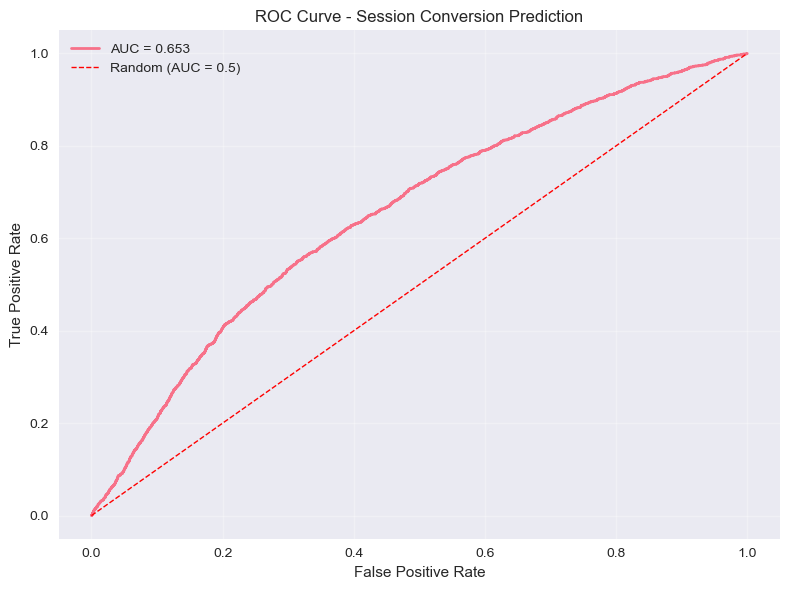

In [14]:
from sklearn.metrics import roc_curve

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, linewidth=2, label=f'AUC = {roc_auc_score(y_test, y_prob):.3f}')
plt.plot([0, 1], [0, 1], 'r--', linewidth=1, label='Random (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Session Conversion Prediction')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('images/logistic_roc_curve.png', dpi=300)
plt.show()

In [15]:
print("Regression Analysis - Key Insights")
print("-" * 40)

print("\n1. Budget → Revenue (R² = 0.216)")
print("   Budget has a significant positive association with revenue.")
print("   Each $1 budget = $6.25 revenue on average.")
print("   Budget explains 21.6% of revenue variation.")

print("\n2. Campaign → ROI (R² = 0.022)")
print("   The model is statistically significant but explains only 2.2% of ROI.")
print("   ROI is difficult to predict from available characteristics.")

print("\n3. Campaign → Revenue (R² = 0.437)")
print("   Pre-campaign variables explain 43.7% of revenue.")
print("   Useful for campaign planning and forecasting.")

print("\n4. Session → Conversion (AUC = 0.653)")
print("   Session behavior predicts conversion with modest accuracy.")
print("   Customer segment and pages viewed are the top predictors.")

Regression Analysis - Key Insights
----------------------------------------

1. Budget → Revenue (R² = 0.216)
   Budget has a significant positive association with revenue.
   Each $1 budget = $6.25 revenue on average.
   Budget explains 21.6% of revenue variation.

2. Campaign → ROI (R² = 0.022)
   The model is statistically significant but explains only 2.2% of ROI.
   ROI is difficult to predict from available characteristics.

3. Campaign → Revenue (R² = 0.437)
   Pre-campaign variables explain 43.7% of revenue.
   Useful for campaign planning and forecasting.

4. Session → Conversion (AUC = 0.653)
   Session behavior predicts conversion with modest accuracy.
   Customer segment and pages viewed are the top predictors.
